# Part 1

### Création du dataset

In [1]:
from sklearn.datasets import make_circles

X, y = make_circles(n_samples=1000, noise=0.03, random_state=42)

In [2]:
print("Dimension de X :", X.shape)
print("Dimension de y :", y.shape)

Dimension de X : (1000, 2)
Dimension de y : (1000,)


* Entrée du classifieur (X) :
dimension 2 =>
chaque point possède 2 caractéristiques (x1, x2)

* Sortie du classifieur (y) :
dimension 1
valeur 0 (classification binaire)

### Data visualization

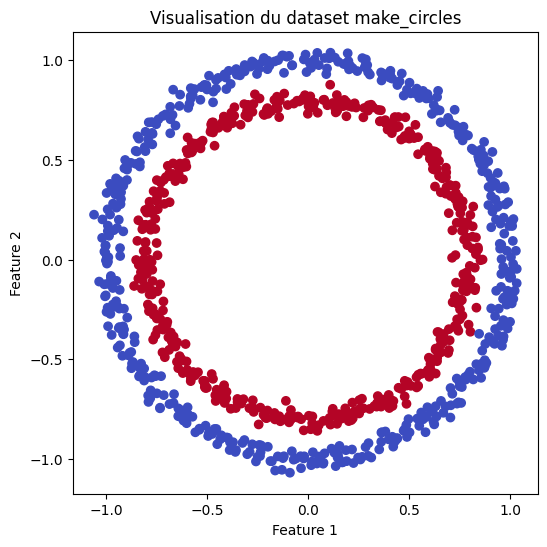

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm')
plt.title("Visualisation du dataset make_circles")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

This dataset requires a non-linear function to separate its classes.

The dataset generated using make_circles() consists of two concentric circles, where one class is located inside the other. Because of this structure, the classes cannot be separated by a straight line (linear decision boundary).

A linear classifier such as logistic regression or a single linear neuron would fail to correctly separate the two classes.


### Splitting the data into training and testing sets

To evaluate the model, the dataset must be divided into:

* Training set (80%) → used to train the model
* Test set (20%) → used to evaluate the model's performance

In [4]:
from sklearn.model_selection import train_test_split

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Display the dimensions
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (800, 2)
Test set shape: (200, 2)


### Creating new model FCNNN

The model will contain one fully connected (Dense) hidden layer with 100 neurons and a sigmoid activation function.

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Create the model
model = Sequential()

# Add a fully connected hidden layer with 100 neurons and sigmoid activation
model.add(Dense(100, activation='sigmoid', input_shape=(2,)))

# output layer
model.add(Dense(1, activation='sigmoid'))

### Display a concise summary of the model architecture

In [11]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 100)            │           300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 401 (1.57 KB)

 Trainable params: 401 (1.57 KB)

 Non-trainable params: 0 (0.00 B)

### Model Compilation
To train the neural network, we must compile the model by specifying:

* Loss function: Binary Cross-Entropy (used for binary classification problems)
* Optimizer: SGD (Stochastic Gradient Descent)
* Metric: Accuracy to evaluate performance

In [12]:
from tensorflow.keras.optimizers import SGD

model.compile(
    loss='binary_crossentropy',
    optimizer=SGD(),
    metrics=['accuracy']
)

### Model Training
We train the neural network for 100 epochs and evaluate its performance on the test dataset.

To display the training progress every 10 epochs, we set verbose=2 (which prints one line per epoch, making it easier to track progress).

In [13]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    validation_data=(X_test, y_test),
    verbose=2
)

Epoch 1/100
25/25 - 1s - 47ms/step - accuracy: 0.4787 - loss: 0.6948 - val_accuracy: 0.5450 - val_loss: 0.6932
Epoch 2/100
25/25 - 0s - 8ms/step - accuracy: 0.5000 - loss: 0.6937 - val_accuracy: 0.5000 - val_loss: 0.6936
Epoch 3/100
25/25 - 0s - 7ms/step - accuracy: 0.5138 - loss: 0.6938 - val_accuracy: 0.4650 - val_loss: 0.6932
Epoch 4/100
25/25 - 0s - 6ms/step - accuracy: 0.4750 - loss: 0.6945 - val_accuracy: 0.4700 - val_loss: 0.6932
Epoch 5/100
25/25 - 0s - 7ms/step - accuracy: 0.5188 - loss: 0.6938 - val_accuracy: 0.5000 - val_loss: 0.6936
Epoch 6/100
25/25 - 0s - 7ms/step - accuracy: 0.4800 - loss: 0.6941 - val_accuracy: 0.4300 - val_loss: 0.6935
Epoch 7/100
25/25 - 0s - 8ms/step - accuracy: 0.4938 - loss: 0.6940 - val_accuracy: 0.4850 - val_loss: 0.6932
Epoch 8/100
25/25 - 0s - 9ms/step - accuracy: 0.5013 - loss: 0.6940 - val_accuracy: 0.4850 - val_loss: 0.6932
Epoch 9/100
25/25 - 0s - 8ms/step - accuracy: 0.4725 - loss: 0.6943 - val_accuracy: 0.5400 - val_loss: 0.6934
Epoch 10/

## Model Evaluation

### Plot the decision boundary for the training and test sets

2813/2813 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step


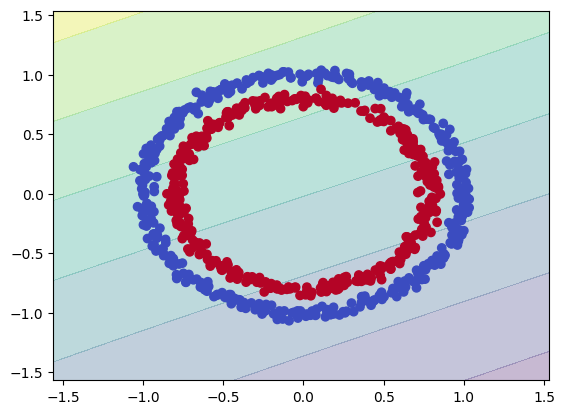

2813/2813 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step


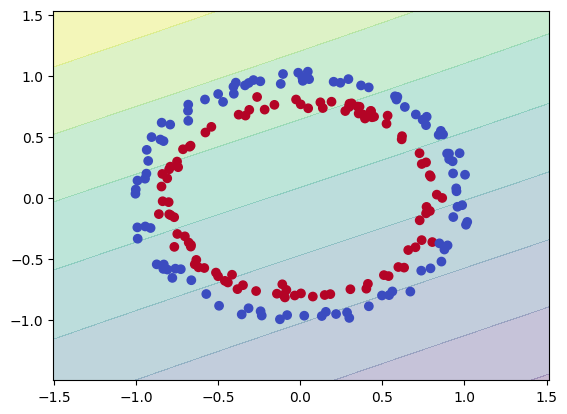

In [14]:
import numpy as np
import matplotlib.pyplot as plt

def plot_decision_boundary(model, X, y):

    x_min, x_max = X[:,0].min() - 0.5, X[:,0].max() + 0.5
    y_min, y_max = X[:,1].min() - 0.5, X[:,1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    predictions = model.predict(grid)
    predictions = predictions.reshape(xx.shape)

    plt.contourf(xx, yy, predictions, alpha=0.3)
    plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm')
    plt.show()

# Training set decision boundary
plot_decision_boundary(model, X_train, y_train)

# Test set decision boundary
plot_decision_boundary(model, X_test, y_test)

### What is the problem with this model?

The base model suffers from underfitting. 

The accuracy bounces randomly between 46% and 53% for the entire second half of training — that is pure random guessing (50/50). The loss stays frozen at ~0.6938 and never meaningfully decreases. This confirms the model is completely stuck and learning nothing.

The decision boundary plots 
Instead of a circle separating the two rings, the model drew diagonal straight lines across the data. That is a linear boundary, which is completely wrong for a circles dataset. The blue and red points are totally mixed up on both train and test, meaning the model cannot separate the two classes at all.

 In short, the model is too shallow and the optimizer too weak to capture the true structure of the data.

# Part 2